# Standardized response mean (SRM) - Sensitivity to change
This notebook contains the analyses related to estimating the sensitivity to change of the considered variables of interest, including measurements and clinical scores.

## Modules

In [1]:
import json
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.transforms import blended_transform_factory

from longitudinal_arm_swing.constants import *
from longitudinal_arm_swing.utils import strip_med_suffix_id, make_json_serializable, calculate_ci, bootstrap_ci

pd.set_option('display.max_columns', 500)

## Constants

In [38]:
filter_type = 'filtered'
signal_or_measurements = 'signal'
l1tf_phased = True
interpolated = True
save_plots = True

measures = ['median', '95p', 'median_cov']
segment_lengths = ['0_20', '20_inf']

path_measures = os.path.join(BASE_PATH, 'measures', f'{filter_type}_gait')
path_survival_probabilities = os.path.join(BASE_PATH, 'measures', 'filtered_gait')
path_figures_paper = r'C:\Users\z665206\Documents\PhD\docs\papers\ppp\paper\tex\imgs'

pd_med_id_filename = 'pd_med_ids.txt'
pd_no_med_id_filename = 'pd_no_med_ids.txt'
ids_remaining_after_exclusions_filename = 'ids_remaining_after_exclusions.json'
aff_side_ids_filename = 'affected_side_ids.json'

start_week = 2
start_weeks = [2, 4, 6]
final_week_1y = 50
final_week_2y = 100
all_weeks_1y = np.arange(start_week, final_week_1y + 1, 2)
all_weeks_2y = np.arange(start_week, final_week_2y + 1, 2)
final_weeks_1y = np.arange(start_week + 2, final_week_1y + 1, 2)
final_weeks_2y = np.arange(start_week + 2, final_week_2y + 1, 2)

clinical_score = 'hypokinesia'
updrs_score_map = [
    ('updrs_3_hand_movement_on_ws', 'Up3OnHaMoYesDev', 'Up3OnHaMoYesDev'),
    ('updrs_3_hand_movement_off_ws', 'Up3OfHaMoYesDev', 'Up3OfHaMoYesDev'),
    ('updrs_3_pro_sup_on_ws', 'Up3OnProSYesDev', 'Up3OnProSYesDev'),
    ('updrs_3_pro_sup_off_ws', 'Up3OfProSYesDev', 'Up3OfProSYesDev'),
    ('updrs_3_finger_tapping_on_ws', 'Up3OnFiTaYesDev', 'Up3OnFiTaYesDev'),
    ('updrs_3_finger_tapping_off_ws', 'Up3OfFiTaYesDev', 'Up3OfFiTaYesDev'),
    ('updrs_3_toe_tapping_on_ws', 'Up3OnToTaYesDev', 'Up3OnToTaYesDev'),
    ('updrs_3_toe_tapping_off_ws', 'Up3OfToTaYesDev', 'Up3OfToTaYesDev'),
    ('updrs_3_leg_agility_on_ws', 'Up3OnLAgiYesDev', 'Up3OnLAgiYesDev'),
    ('updrs_3_leg_agility_off_ws', 'Up3OfLAgiYesDev', 'Up3OfLAgiYesDev'),
    ('updrs_3_rigidity_lower_extremity_on_ws', 'Up3OnRigLle', 'Up3OnRigRle'),
    ('updrs_3_rigidity_lower_extremity_off_ws', 'Up3OfRigLle', 'Up3OfRigRle'),
    ('updrs_3_rigidity_upper_extremity_on_ws', 'Up3OnRigLue', 'Up3OnRigRue'),
    ('updrs_3_rigidity_upper_extremity_off_ws', 'Up3OfRigLue', 'Up3OfRigRue'),
    ('updrs_3_off_gait', 'Up3OfGait', 'Up3OfGait'),
    ('updrs_3_on_gait', 'Up3OnGait', 'Up3OnGait'),
]

updrs_scores = ['updrs_1_total', 'updrs_2_total', 'Updrs2It12', 'Up3OfGait', 'Up3OnGait'] + [
                f'updrs_3_{score}' for score in [
                    'off_total', 'on_total', 'hypokinesia_off_ws', 'hypokinesia_on_ws', 
                    'bradykinesia_off_ws', 'bradykinesia_on_ws', 'rigidity_off_ws', 
                    'rigidity_on_ws'
                ]] + [updrs_score_map[i][0] for i in range(len(updrs_score_map))]

## Functions

In [3]:
def bootstrap_and_compute_sensitivity_to_change(values, B=1000, weights=None, method='srm', seed=None):
    if method not in ['srm', 'srm_robust', 'rprb']:
        raise ValueError("Invalid method. Choose 'srm', 'srm_robust', or 'rprb'.")
    
    if method == 'rprb' and weights is not None:
        raise ValueError("Rank-pairs rank biserial correlation (rprb) does not support weights.")
    
    N = len(values)
    if N == 0:
        return np.nan, np.nan, np.nan, np.nan, np.nan, np.nan
        
    rng = np.random.default_rng(seed)
    boot_stats = []

    for _ in range(B):
        sampled_indices = rng.integers(low=0, high=N, size=N)
        sampled_values = values[sampled_indices]

        if weights is None:
            if method == "srm":
                mean_change = np.mean(sampled_values)
                std_change = np.std(sampled_values, ddof=1)
                stat = mean_change / std_change if std_change != 0 else np.nan

            elif method == "srm_robust":
                median_change = np.median(sampled_values)
                mad = np.median(np.abs(sampled_values - median_change))
                stat = median_change / mad if mad != 0 else np.nan

            elif method == "rprb":
                n_pos = np.sum(sampled_values > 0)
                n_neg = np.sum(sampled_values < 0)
                n_total = n_pos + n_neg
                stat = (n_pos - n_neg) / n_total if n_total != 0 else np.nan

            boot_stats.append(stat)

        else:
            sampled_weights = weights[sampled_indices]
            weight_sum = np.nansum(sampled_weights)
            if weight_sum == 0:
                boot_stats.append(np.nan)
                continue
            
            if method == "srm":
                mean_change = np.nansum(sampled_values * sampled_weights) / weight_sum
                var_change = np.nansum(((sampled_values - mean_change) ** 2) * sampled_weights) / weight_sum
                std_change = np.sqrt(var_change)
                stat = mean_change / std_change if std_change != 0 else np.nan
            elif method == "srm_robust":
                median_change = np.median(sampled_values)
                mad = np.median(np.abs(sampled_values - median_change))
                stat = median_change / mad if mad != 0 else np.nan

            boot_stats.append(stat)

    # Point estimate
    if weights is None:
        if method == "srm":
            mean_change = np.mean(values)
            std_change = np.std(values, ddof=1)
            point_est = mean_change / std_change if std_change != 0 else np.nan
            desc1, desc2 = mean_change, std_change

        elif method == "srm_robust":
            median_change = np.median(values)
            mad = np.median(np.abs(values - median_change))
            point_est = median_change / mad if mad != 0 else np.nan
            desc1, desc2 = median_change, mad

        elif method == "rprb":
            n_pos = np.sum(values > 0)
            n_neg = np.sum(values < 0)
            n_total = n_pos + n_neg
            point_est = (n_pos - n_neg) / n_total if n_total != 0 else np.nan
            desc1, desc2 = np.nan, np.nan
    else:
        weight_sum = np.nansum(weights)

        if method == "srm":
            mean_change = np.nansum(values * weights) / weight_sum
            var_change = np.nansum(((values - mean_change) ** 2) * weights) / weight_sum
            std_change = np.sqrt(var_change)
            point_est = mean_change / std_change if std_change != 0 else np.nan
            desc1, desc2 = mean_change, std_change

        elif method == "srm_robust":
            median_change = np.median(values)
            mad = np.nansum(np.abs(values - median_change) * weights) / weight_sum
            point_est = median_change / mad if mad != 0 else np.nan
            desc1, desc2 = median_change, mad

    boot_stats = np.array(boot_stats)
    ci_lower, ci_upper = np.nanpercentile(boot_stats, [2.5, 97.5])
    p_val = 2 * min(np.mean(boot_stats <= 0), np.mean(boot_stats >= 0))

    return desc1, desc2, point_est, ci_lower, ci_upper, p_val

# Load

In [4]:
prepared_data = {}
for group in ['pd', 'controls']:
    prepared_data[group] = {}
    for segment_length in segment_lengths:
        prepared_data[group][segment_length] = {
            'measurements': {},
            'signal': {},
        }
        for measure in measures:
            measure_extended = f'{measure}_range_of_motion'
            if group == 'pd':
                if l1tf_phased:
                    prepared_data[group][segment_length]['signal'][measure] = pd.DataFrame()
                    for file in os.listdir(os.path.join(path_measures, segment_length, 'lambda_fit_by_duration')):
                        if file.startswith(f'{group}_signal_interp_{measure_extended}_'):
                            week_nr = int(file.split('_')[-1].split('.')[0].replace('w', ''))
                            if week_nr not in prepared_data[group][segment_length]['signal']:
                                df_week = pd.read_csv(os.path.join(path_measures, segment_length, 'lambda_fit_by_duration', file))
                                prepared_data[group][segment_length]['signal'][measure][f'week{week_nr}'] = df_week[f'week{week_nr}']

                    med_data = pd.read_csv(os.path.join(path_measures, segment_length, f'{group}_med_measure_{measure_extended}.csv'))
                    no_med_data = pd.read_csv(os.path.join(path_measures, segment_length, f'{group}_no_med_measure_{measure_extended}.csv'))
                    df_pd_tmp = pd.concat([med_data, no_med_data], ignore_index=True)
                    df_pd_tmp.columns = [f'week{week}' for week in df_pd_tmp.columns]

                    for week in [2, 4, 6]:
                        prepared_data[group][segment_length]['signal'][measure][f'week{week}'] = df_pd_tmp[f'week{week}']
                else:
                    med_data = pd.read_csv(os.path.join(path_measures, segment_length, f'{group}_med_measure_{measure_extended}.csv'))
                    no_med_data = pd.read_csv(os.path.join(path_measures, segment_length, f'{group}_no_med_measure_{measure_extended}.csv'))
                    prepared_data[group][segment_length]['measurements'][measure] = pd.concat([med_data, no_med_data], ignore_index=True)
            else:
                prepared_data[group][segment_length]['measurements'][measure] = pd.read_csv(os.path.join(path_measures, segment_length, f'{group}_measure_{measure_extended}.csv'))

            if not l1tf_phased:
                prepared_data[group][segment_length]['measurements'][measure].columns = [f'week{week}' for week in prepared_data[group][segment_length]['measurements'][measure].columns]

            if interpolated and not l1tf_phased:
                prepared_data[group][segment_length]['signal'][measure] = pd.read_csv(os.path.join(path_measures, segment_length, f'{group}_signal_interp_{measure_extended}.csv'))
            elif not l1tf_phased:
                prepared_data[group][segment_length]['signal'][measure] = pd.read_csv(os.path.join(path_measures, segment_length, f'{group}_signal_{measure_extended}.csv'))

df_measures_inclusion = pd.read_parquet(os.path.join(BASE_PATH, 'measures', 'digital_measures.parquet'))
df_clinical = pd.read_parquet(os.path.join(PATH_CLINICAL_DATA, 'clinical_data.parquet'))

with open(os.path.join(path_measures, '20_inf', 'pd_med_ids.txt'), 'r') as f:
    pd_med_ids = f.read().splitlines()

with open(os.path.join(path_measures, '20_inf', 'pd_no_med_ids.txt'), 'r') as f:
    pd_no_med_ids = f.read().splitlines()

pd_no_med_ids = [c for c in pd_no_med_ids if c != 'POMUEE612759679A830D']
with open(os.path.join(path_measures, '20_inf', 'pd_no_med_ids.txt'), 'w') as f:
    f.write('\n'.join(pd_no_med_ids))

with open(os.path.join(path_measures, '20_inf', 'controls_ids.txt'), 'r') as f:
    controls_ids = f.read().splitlines()

with open(os.path.join(PATH_IDS, ids_remaining_after_exclusions_filename), 'r') as f:
    ids_remaining_after_exclusions = json.load(f)

with open(os.path.join(PATH_IDS, aff_side_ids_filename), 'r') as f:
    aff_side_ids = json.load(f)

with open(os.path.join(PATH_IDS, 'med_info_ids.json'), 'r') as f:
    med_info_ids = json.load(f)

with open(os.path.join(PATH_IDS, 'excluded_ids_by_category.json'), 'r') as f:
    excluded_ids_by_category = json.load(f)

with open(os.path.join(PATH_IDS, 'ids_late_visit_3.txt'), 'r') as f:
    ids_late_visit_3 = f.read().splitlines()

survival_probabilities = {}
for med_state, min_week in zip(['med', 'no_med'], [50, 2]):
    survival_probabilities[med_state] = {}
    for measure in measures:
        survival_probabilities[med_state][measure] = pd.read_csv(os.path.join(path_survival_probabilities, f'survival_probabilities_{med_state}.csv'))
        survival_probabilities[med_state][measure] = (
            survival_probabilities[med_state][measure].pivot(index='id', columns='week', values='survival_prob')
            .reset_index()
            .rename_axis(None, axis=1)
            .rename(columns={col: f'week{col}' for col in range(min_week, 101, 2)})
        )

start_med_week_dict = {
    'ppp': pd.read_csv(os.path.join(PATH_CLINICAL_DATA, 'ppp', PPP_START_MED_FILENAME)),
    'denovo': pd.read_csv(os.path.join(PATH_CLINICAL_DATA, 'denovo', DENOVO_START_MED_WEEK_FILENAME))
}

# Prepare data

In [5]:
for new_col, left_col, right_col in updrs_score_map:
    df_clinical.loc[df_clinical['WatchSide'] == 'left', new_col] = df_clinical.loc[df_clinical['WatchSide'] == 'left', left_col]
    df_clinical.loc[df_clinical['WatchSide'] == 'right', new_col] = df_clinical.loc[df_clinical['WatchSide'] == 'right', right_col]

In [6]:
pd_ids = pd_med_ids + pd_no_med_ids

idx_med_ids = [pd_ids.index(x) for x in pd_med_ids if x in pd_ids]
idx_no_med_ids = [len(pd_med_ids) + pd_no_med_ids.index(x) for x in pd_no_med_ids if x in pd_ids]

ids_2y = ids_remaining_after_exclusions['ppp']['srm_2y'] + ids_remaining_after_exclusions['denovo']['srm_2y']
ids_y1 = ids_remaining_after_exclusions['ppp']['srm_1y'] + ids_remaining_after_exclusions['denovo']['srm_1y']

get_week_ppp = lambda id: start_med_week_dict['ppp'].loc[start_med_week_dict['ppp']['ID'] == id, 'StartWeek'].values[0]
get_week_denovo = lambda id: start_med_week_dict['denovo'].loc[start_med_week_dict['denovo']['ID'] == id, 'StartWeek'].values[0]

start_med_ids = [strip_med_suffix_id(id) for id in ids_remaining_after_exclusions['ppp']['l1tf_start_med'] if get_week_ppp(strip_med_suffix_id(id)) < 100] + \
    [strip_med_suffix_id(id) for id in ids_remaining_after_exclusions['denovo']['l1tf_start_med'] if get_week_denovo(strip_med_suffix_id(id)) < 100]

start_med_early_ids = [strip_med_suffix_id(id) for id in ids_remaining_after_exclusions['ppp']['l1tf_start_med'] if get_week_ppp(strip_med_suffix_id(id)) < 8] + \
    [strip_med_suffix_id(id) for id in ids_remaining_after_exclusions['denovo']['l1tf_start_med'] if get_week_denovo(strip_med_suffix_id(id)) < 8]

delta_scores = {}
srm_ids_per_week = {}

for segment_length in segment_lengths:
    delta_scores[segment_length] = {}
    srm_ids_per_week[segment_length] = {}

    if not l1tf_phased:
        ids_valid_start_week = [
            pd_ids[x] for x in prepared_data['pd'][segment_length][signal_or_measurements]['median'].loc[
                prepared_data['pd'][segment_length][signal_or_measurements]['median']['week2'].notna()
            ].index 
        ]
        ids_valid_final_week_y1 = [
            pd_ids[x] for x in prepared_data['pd'][segment_length][signal_or_measurements]['median'].loc[
                prepared_data['pd'][segment_length][signal_or_measurements]['median']['week50'].notna()
            ].index 
        ]
        ids_valid_final_week_y2 = [
            pd_ids[x] for x in prepared_data['pd'][segment_length][signal_or_measurements]['median'].loc[
                prepared_data['pd'][segment_length][signal_or_measurements]['median']['week100'].notna()
            ].index 
        ]

    for side in ['mas', 'las']:
        relevant_aff_side_ids = aff_side_ids['ppp'][side] + aff_side_ids['denovo'][side]
        for med_status, ids_status in zip(['med', 'no_med'], [pd_med_ids, pd_no_med_ids]):
            key_prefix = f'pd_{side}_{med_status}'
            delta_scores[segment_length][key_prefix] = {}
            srm_ids_per_week[segment_length][key_prefix] = {}
            
            ids_visits_12 = df_clinical.loc[df_clinical['visit'].isin([1, 2])]['id'].value_counts().loc[lambda x: x == 2].index.tolist()
            ids_visits_13 = df_clinical.loc[df_clinical['visit'].isin([1, 3])]['id'].value_counts().loc[lambda x: x == 2].index.tolist()

            # Also check whether participant is included in srm analysis (has valid arm swing weeks in final weeks)
            ids_visits_12 = [id for id in ids_visits_12 if id in ids_valid_final_week_y1 and id in ids_y1]
            ids_visits_13 = [id for id in ids_visits_13 if id in ids_valid_final_week_y2 and id in ids_2y]

            df_clinical_filtered = df_clinical[(df_clinical['id'].isin(ids_status)) & (df_clinical['id'].isin(relevant_aff_side_ids)) & (df_clinical['id'].isin(ids_valid_start_week)) & (~df_clinical['id'].isin(ids_late_visit_3))]
            df_clinical_filtered = df_clinical_filtered.drop_duplicates(subset=['id', 'visit'], keep='first')  # Due to starting medication participants

            for score in updrs_scores:
                df_v1 = df_clinical_filtered[df_clinical_filtered['visit'] == 1][['id', score]].rename(columns={score: f'{score}_v1'})
                df_v2 = df_clinical_filtered[df_clinical_filtered['visit'] == 2][['id', score]].rename(columns={score: f'{score}_v2'})
                df_v3 = df_clinical_filtered[df_clinical_filtered['visit'] == 3][['id', score]].rename(columns={score: f'{score}_v3'})

                # Merge for 1y (visit 2)
                df_12 = pd.merge(df_v1, df_v2, on='id')
                df_12['delta'] = df_12[f'{score}_v2'] - df_12[f'{score}_v1']
                df_12 = df_12[df_12['id'].isin(ids_visits_12) & df_12['delta'].notna()]

                # Merge for 2y (visit 3)
                df_13 = pd.merge(df_v1, df_v3, on='id')
                df_13['delta'] = df_13[f'{score}_v3'] - df_13[f'{score}_v1']
                df_13 = df_13[df_13['id'].isin(ids_visits_13) & df_13['delta'].notna()]

                delta_scores[segment_length][key_prefix][score] = {
                    '1y': {
                        'ids': df_12['id'].tolist(),
                        'unweighted': df_12['delta'].tolist()
                    },
                    '2y': {
                        'ids': df_13['id'].tolist(),
                        'unweighted': df_13['delta'].tolist()
                    }
                }

            for measure in measures:
                delta_scores[segment_length][key_prefix][measure] = {}
                df_measure = prepared_data['pd'][segment_length][signal_or_measurements][measure]

                if df_measure.shape[0] == 511:
                    df_measure = df_measure.drop(509)

                df_measure['id'] = pd_ids
                    
                df_measure_filtered = df_measure[
                    (df_measure['id'].isin(ids_status)) & 
                    (df_measure['id'].isin(relevant_aff_side_ids)) & 
                    (df_measure['id'].isin(ids_valid_start_week)) &
                    (df_measure.index.isin(idx_med_ids if med_status == 'med' else idx_no_med_ids))
                ]            

                df_surv = survival_probabilities[med_status][measure].copy()

                surv_ids = df_surv['id'].values.tolist()

                ids_final_week_measure = [pd_ids[x] for x in prepared_data['pd'][segment_length][signal_or_measurements]['median'].loc[
                    (prepared_data['pd'][segment_length][signal_or_measurements]['median'][f'week{final_week_2y}'].notna()) &
                    (prepared_data['pd'][segment_length][signal_or_measurements]['median'][f'week{start_week}'].notna())
                ].index if pd_ids[x] in df_measure_filtered['id'].values]

                static_ids = [id for id in ids_final_week_measure if id in ids_2y]

                ids_week_measure = [
                    pd_ids[x] for x in prepared_data['pd'][segment_length][signal_or_measurements]['median'].loc[
                        prepared_data['pd'][segment_length][signal_or_measurements]['median'][f'week{start_week}'].notna()
                    ].index if pd_ids[x] in df_measure_filtered['id'].values
                ]
                srm_ids_per_week[segment_length][key_prefix][2] = [id for id in ids_week_measure if id not in start_med_early_ids]

                for week in final_weeks_2y:
                    ids_week_measure = [pd_ids[x] for x in prepared_data['pd'][segment_length][signal_or_measurements]['median'].loc[
                        (prepared_data['pd'][segment_length][signal_or_measurements]['median'][f'week{week}'].notna()) &
                        (prepared_data['pd'][segment_length][signal_or_measurements]['median'][f'week{start_week}'].notna())
                    ].index if pd_ids[x] in df_measure_filtered['id'].values]

                    srm_ids_per_week[segment_length][key_prefix][int(week)] = [id for id in ids_week_measure if id not in start_med_early_ids]

                    df_dynamic = df_measure_filtered.loc[
                        (df_measure_filtered['id'].isin(ids_week_measure)) & 
                        (~df_measure_filtered['id'].isin(start_med_early_ids)) &
                        (df_measure_filtered['id'].isin(surv_ids))
                    ]
                    ids_dynamic = df_dynamic['id'].values.tolist()
                    start_week_vals_dynamic = df_dynamic[f'week{start_week}'].values
                    current_week_vals_dynamic = df_dynamic[f'week{week}'].values

                    df_static = df_measure_filtered.loc[
                        (df_measure_filtered['id'].isin(ids_week_measure)) & 
                        (~df_measure_filtered['id'].isin(start_med_ids)) &
                        (df_measure_filtered['id'].isin(surv_ids)) &
                        (df_measure_filtered['id'].isin(static_ids))
                    ]
                    ids_static = df_static['id'].values.tolist()
                    start_week_vals_static = df_static[f'week{start_week}'].values 
                    current_week_vals_static = df_static[f'week{week}'].values
                    
                    delta_scores[segment_length][key_prefix][measure][f'dynamic_{week}'] = {
                        'ids': ids_dynamic,
                        'unweighted': current_week_vals_dynamic - start_week_vals_dynamic
                    }
                    delta_scores[segment_length][key_prefix][measure][f'static_{week}'] = {
                        'ids': ids_static,
                        'unweighted': current_week_vals_static - start_week_vals_static
                    }

                    if week >= start_week:
                        for setup, setup_ids in zip(['static', 'dynamic'], [ids_static, ids_dynamic]):
                            if med_status == 'med' and week < 50:
                                delta_scores[segment_length][key_prefix][measure][f'{setup}_{week}']['weights'] = np.ones(len(setup_ids))
                            else:
                                df_surv_setup = df_surv.loc[(df_surv['id'].isin(ids_week_measure)) & ~(df_surv['id'].isin(start_med_early_ids)) & (df_surv['id'].isin(setup_ids))].copy()

                                if df_surv_setup.empty:
                                    delta_scores[segment_length][key_prefix][measure][f'{setup}_{week}']['weights'] = np.ones(len(setup_ids))
                                    continue
                                
                                ids_surv_setup = df_surv_setup['id'].values.tolist()
                                weights_week_setup = 1 / df_surv_setup[f'week{week}'].values

                                # Map weights onto ids
                                weights_mapping = dict(zip(ids_surv_setup, weights_week_setup))
                                weights_week = np.array([weights_mapping.get(id, 0) for id in setup_ids])

                                delta_scores[segment_length][key_prefix][measure][f'{setup}_{week}']['weights'] = weights_week
                            
    if not l1tf_phased:
        key_prefix = 'controls'

        delta_scores[segment_length][key_prefix] = {}
        srm_ids_per_week[segment_length][key_prefix] = {}
        ids_both_visits = df_clinical.loc[df_clinical['visit'].isin([1, 2])]['id'].value_counts().loc[lambda x: x == 2].index.tolist()
        df_clinical_filtered = df_clinical[(df_clinical['dataset'] == 'controls') & (df_clinical['id'].isin(ids_both_visits))]

        final_week_ids = [controls_ids[x] for x in prepared_data['controls'][segment_length][signal_or_measurements]['median'].loc[
            prepared_data['controls'][segment_length][signal_or_measurements]['median'][f'week{final_week_1y}'].notna()
        ].index]

        for measure in measures:
            delta_scores[segment_length][key_prefix][measure] = {}
            df_measure = prepared_data['controls'][segment_length][signal_or_measurements][measure]
            df_measure['id'] = controls_ids

            ids_week_measure = [
                controls_ids[x] for x in prepared_data['controls'][segment_length][signal_or_measurements]['median'].loc[
                    prepared_data['controls'][segment_length][signal_or_measurements]['median'][f'week{start_week}'].notna()
                ].index
            ]
            srm_ids_per_week[segment_length][key_prefix][start_week] = ids_week_measure
            
            for week in final_weeks_1y:
                # Check where both values are not NaN
                ids_week_measure = [controls_ids[x] for x in prepared_data['controls'][segment_length][signal_or_measurements]['median'].loc[
                    (prepared_data['controls'][segment_length][signal_or_measurements]['median'][f'week{week}'].notna()) &
                    (prepared_data['controls'][segment_length][signal_or_measurements]['median'][f'week{start_week}'].notna())
                ].index]
                srm_ids_per_week[segment_length][key_prefix][int(week)] = ids_week_measure

                delta_dynamic = df_measure[f'week{week}'].values - df_measure[f'week{start_week}'].values
                delta_scores[segment_length][key_prefix][measure][f'dynamic_{week}'] = {
                    'ids': ids_week_measure,
                    'unweighted': delta_dynamic
                }

                static_ids = [id for id in final_week_ids if id in ids_week_measure]
                delta_static = df_measure.loc[df_measure['id'].isin(final_week_ids), f'week{week}'].values - df_measure.loc[df_measure['id'].isin(final_week_ids), f'week{start_week}'].values
                delta_scores[segment_length][key_prefix][measure][f'static_{week}'] = {
                    'ids': static_ids,
                    'unweighted': delta_static
                }

with open(os.path.join(PATH_IDS, 'srm_ids_per_week.json'), 'w') as f:
    json.dump(srm_ids_per_week, f, indent=4)

NameError: name 'ids_valid_final_week_y1' is not defined

In [ ]:
for segment_length, segment_vals in delta_scores.items():
    for group, group_vals in segment_vals.items():
        if 'no_med' in group:
            ids_focus = pd_no_med_ids
        elif 'med' in group:
            ids_focus = pd_med_ids
        else:
            continue
        for measure, measure_vals in group_vals.items():
            if 'updrs' in measure or 'Updrs' in measure or 'Up3' in measure:
                for scope, scope_vals in measure_vals.items():
                    if scope == '1y':
                        scope_week = 50
                    else:
                        scope_week = 100

                    ids_with_measure = [id for id in scope_vals['ids'] if id in group_vals['95p'][f'dynamic_{scope_week}']['ids']]
                    idx_list = [group_vals['95p'][f'dynamic_{scope_week}']['ids'].index(id) for id in ids_with_measure]
                    weights = [group_vals['95p'][f'dynamic_{scope_week}']['weights'][idx] for idx in idx_list]

                    delta_scores[segment_length][group][measure][scope]['weights'] = weights

if l1tf_phased:
    filename = 'delta_scores_l1tf_phased.json'
else:
    filename = 'delta_scores.json'

with open(os.path.join(path_measures, filename), 'w') as f:
    json.dump(make_json_serializable(delta_scores), f, indent=4)

In [31]:
srm_stats = []
method = 'srm'
n_boostraps = 2000
seed = 42

for segment_length, segment_vals in delta_scores.items():
    for group, group_vals in segment_vals.items():
        for measure, measure_vals in group_vals.items():
            for scope, scope_vals in measure_vals.items():
                if measure in updrs_scores:
                    continue
                ids = scope_vals['ids']
                vals = np.asarray(scope_vals['unweighted'])
                weighted = 'weights' in scope_vals

                if weighted and method != 'rprb':
                    weights = np.asarray(scope_vals['weights'])
                    # If fewer weights than values, trim vals/ids accordingly
                    if len(weights) < len(vals):
                        vals = vals[:len(weights)]
                        ids = ids[:len(weights)]
                    elif len(weights) > len(vals):
                        weights = weights[:len(vals)]

                else:
                    weights = None

                # Remove NaNs
                nan_mask = ~np.isnan(vals)
                vals = vals[nan_mask]
                if weighted and method != 'rprb':
                    weights = weights[nan_mask]

                if weighted and method != 'rprb' and len(vals) > 0 and len(weights) == len(vals):
                    pe_avg, pe_dev, pe_stat, boot_ci_lower, boot_ci_upper, boot_p_val = bootstrap_and_compute_sensitivity_to_change(vals, n_boostraps, weights=weights, method=method, seed=seed)
                    srm_stats.append([group, segment_length, measure, scope, True, len(vals), pe_avg, pe_dev, pe_stat, boot_ci_lower, boot_ci_upper, boot_p_val])

                # Also compute unweighted SRM
                if len(vals) > 0:
                    pe_avg, pe_dev, pe_stat, boot_ci_lower, boot_ci_upper, boot_p_val = bootstrap_and_compute_sensitivity_to_change(vals, n_boostraps, weights=None, method=method, seed=seed)
                    srm_stats.append([group, segment_length, measure, scope, False, len(vals), pe_avg, pe_dev, pe_stat, boot_ci_lower, boot_ci_upper, boot_p_val])

if method == 'srm':
    stat_cols = ['Mean', 'Std', 'SRM']
elif method == 'srm_robust':
    stat_cols = ['Median', 'MAD', 'SRM']
elif method == 'rprb':
    stat_cols = ['Mean', 'Std', 'RPRB']

df_srm = pd.DataFrame(srm_stats, columns=['group', 'segment_length', 'measure', 'scope', 'weighted', 'N'] + stat_cols + ['ci_lower', 'ci_upper', 'pvalue'])

if l1tf_phased:
    filename = f'df_{method}_{signal_or_measurements}_l1tf_phased_preprocessed.csv'
else:
    filename = f'df_{method}_{signal_or_measurements}_preprocessed.csv'
    
df_srm.to_csv(os.path.join(path_measures, filename), index=False)

### Measurement correlations

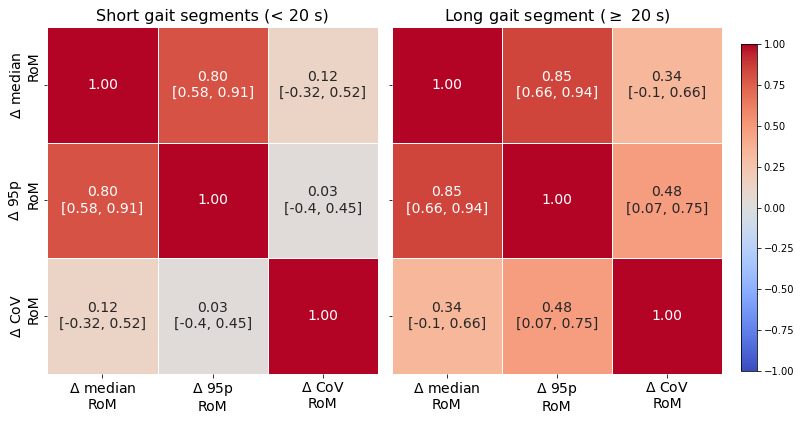

In [ ]:
import seaborn as sns
from scipy.stats import spearmanr

med_status = 'no_med'
static_or_dynamic = 'static'
final_week = 100

plot_vals = 'ci'  # or 'pvals'

fig, ax = plt.subplots(ncols=2, figsize=(12, 6), sharey=True)

for j, segment_length in enumerate(segment_lengths):

    for k, side in enumerate(['mas','las']):
        delta_scores_focus = delta_scores[segment_length][f'pd_{side}_{med_status}']

        if k == 0:
            delta_median = delta_scores_focus['median'][f'{static_or_dynamic}_{final_week}']['unweighted']
            delta_95p = delta_scores_focus['95p'][f'{static_or_dynamic}_{final_week}']['unweighted']
            delta_cv = delta_scores_focus['median_cov'][f'{static_or_dynamic}_{final_week}']['unweighted']
        else:
            delta_median = np.concatenate((delta_median, delta_scores_focus['median'][f'{static_or_dynamic}_{final_week}']['unweighted']))
            delta_95p = np.concatenate((delta_95p, delta_scores_focus['95p'][f'{static_or_dynamic}_{final_week}']['unweighted']))
            delta_cv = np.concatenate((delta_cv, delta_scores_focus['median_cov'][f'{static_or_dynamic}_{final_week}']['unweighted']))

    corr_input_df = pd.DataFrame({
        '$\Delta$ median\nRoM': delta_median,
        '$\Delta$ 95p\nRoM': delta_95p,
        '$\Delta$ CoV\nRoM': delta_cv,
    })

    corr_df = corr_input_df.corr(method='spearman')
    annot_df = corr_df.copy().astype(str)

    for row in corr_df.columns:
        for col in corr_df.columns:
            if row == col:
                annot_df.loc[row, col] = "1.00"
                continue

            x = corr_input_df[row]
            y = corr_input_df[col]
            valid_idx = (~x.isnull()) & (~y.isnull())
            corr, p_val = spearmanr(x[valid_idx], y[valid_idx])

            if plot_vals == 'pvals':
                if p_val < 0.001:
                    lower_label = "(p < 0.001)"
                elif p_val < 0.01:
                    lower_label = "(p < 0.01)"
                elif p_val < 0.05:
                    lower_label = "(p < 0.05)"
                else:
                    lower_label = f"(p = {np.round(p_val, 2)})"
            elif plot_vals == 'ci':
                lower, upper = calculate_ci(x[valid_idx], corr) 
                lower_label = f"[{np.round(lower, 2)}, {np.round(upper, 2)}]"

            annot_df.loc[row, col] = f"{np.round(corr, 2)}\n{lower_label}"

    sns.heatmap(
        corr_df,
        annot=annot_df,
        fmt="",
        cmap="coolwarm",
        center=0,
        linewidths=0.5,
        cbar=False,
        vmin=-1, vmax=1,
        annot_kws={"size": PLOT_TEXTSIZE},
        ax=ax[j]
    )

    ax[j].tick_params(axis='both', which='major', labelsize=PLOT_TICKSIZE)

im = ax[1].collections[0]
fig.colorbar(im, ax=ax, orientation="vertical", fraction=0.05, pad=0.04)

ax[0].set_title('Short gait segments (< 20 s)', size=PLOT_LABELSIZE)
ax[1].set_title('Long gait segment ($\geq$ 20 s)', size=PLOT_LABELSIZE)

plt.tight_layout()
plt.subplots_adjust(top=0.92, right=0.84)
plt.show()

if save_plots:
    fig.savefig(os.path.join(PATH_FIGURES, f'sr_lng_corr_measures_{filter_type}.png'), dpi=600, bbox_inches='tight')
    fig.savefig(os.path.join(PATH_FIGURES, 'vectors', f'sr_lng_corr_measures_{filter_type}.pdf'), dpi=600, bbox_inches='tight')


### Delta scores

In [75]:
group = 'controls'
segment_length = '20_inf'
measure = 'median'
final_week = 50

sample = delta_scores[segment_length][group][measure][f'static_{final_week}']['unweighted']

b_lower, b_upper = bootstrap_ci(sample)
point_estimate = np.nanmean(sample)

print(f"Point estimate: {np.round(point_estimate, 2)}")
print(f"Bootstrap CI: ({np.round(b_lower, 2)}, {np.round(b_upper, 2)})")

Point estimate: -0.49
Bootstrap CI: (-1.47, 0.46)


# Plot SRM

In [32]:
# If appropriate, load pre-computed data
base_path = os.path.dirname(path_measures)

df_srm = pd.DataFrame()

for filter_type in ['unfiltered', 'filtered']:
    for signal_or_measurements in ['signal', 'measurements']:
        for method, suffix in zip(['phased', 'full'], ['l1tf_phased_', '']):
            filename = f'df_srm_{signal_or_measurements}_{suffix}preprocessed.csv'
            full_path = os.path.join(base_path, f'{filter_type}_gait', filename)

            if os.path.exists(full_path):
                df_srm_subset = pd.read_csv(os.path.join(base_path, f'{filter_type}_gait', filename))

                df_srm_subset['method'] = method
                df_srm_subset['filter_type'] = filter_type
                df_srm_subset['signal_or_measurements'] = signal_or_measurements

                df_srm = pd.concat([df_srm, df_srm_subset], ignore_index=True)

df_srm = df_srm.reset_index(drop=True)

### Static

In [33]:
focus_score_med_cols = measures + updrs_scores
focus_score_no_med_cols = measures + [x for x in updrs_scores if 'off' in x or 'total' in x]

sort_dict = {'median': 0, '95p': 1, 'median_cov': 2, f'updrs_3_{clinical_score}_off_ws': 3, f'updrs_3_{clinical_score}_on_ws': 4}

df_srm_static = df_srm.copy()

df_srm_static['med_status'] = df_srm_static['group'].apply(lambda x: 'no_med' if '_no_med' in x else 'med' if '_med' in x else 'controls')
df_srm_static['side'] = df_srm['group'].apply(lambda x: x.split('_')[1] if '_' in x else x)

df_srm_static = df_srm_static.sort_values(by=['measure', 'side'], key=lambda x: x.map(sort_dict))

measure_extended_map = {
    'median': 'Median RoM',
    '95p': r'95$^{\mathrm{th}}$ percentile RoM',
    'median_cov': 'CoV RoM',
    'updrs_1_total': 'UPDRS Part 1 total',
    'updrs_2_total': 'UPDRS Part 2 total',
    'Updrs2It12': 'UPDRS Part 2 item 12',
    'updrs_3_off_total': 'UPDRS Part 3 OFF total',
    'updrs_3_on_total': 'UPDRS Part 3 ON total',
    'Up3OfGait': 'UPDRS Part 3 OFF gait',
    'Up3OnGait': 'UPDRS Part 3 ON gait',
    'updrs_3_pro_sup_off_ws': 'UPDRS Part 3 OFF pronation-supination',
    'updrs_3_pro_sup_on_ws': 'UPDRS Part 3 ON pronation-supination',
    'updrs_3_finger_tapping_off_ws': 'UPDRS Part 3 OFF finger tapping',
    'updrs_3_finger_tapping_on_ws': 'UPDRS Part 3 ON finger tapping',
    'updrs_3_toe_tapping_off_ws': 'UPDRS Part 3 OFF toe tapping',
    'updrs_3_toe_tapping_on_ws': 'UPDRS Part 3 ON toe tapping',
    'updrs_3_leg_agility_off_ws': 'UPDRS Part 3 OFF leg agility',
    'updrs_3_leg_agility_on_ws': 'UPDRS Part 3 ON leg agility',
    'updrs_3_hand_movement_off_ws': 'UPDRS Part 3 OFF hand movement',
    'updrs_3_hand_movement_on_ws': 'UPDRS Part 3 ON hand movement',
    'updrs_3_rigidity_upper_extremity_on_ws': 'UPDRS Part 3 ON rigidity upper extremity',
    'updrs_3_rigidity_upper_extremity_off_ws': 'UPDRS Part 3 OFF rigidity upper extremity',
    'updrs_3_rigidity_lower_extremity_on_ws': 'UPDRS Part 3 ON rigidity lower extremity',
    'updrs_3_rigidity_lower_extremity_off_ws': 'UPDRS Part 3 OFF rigidity lower extremity',
}

measure_length_map = {
    'median 0_20': 'Median RoM - Short',
    'median 20_inf': 'Median RoM - Long',
    '95p 0_20': '95th percentile RoM - Short',
    '95p 20_inf': '95th percentile RoM - Long',
    'median_cov 0_20': 'CoV RoM - Short',
    'median_cov 20_inf': 'CoV RoM - Long',
}

for symptom in ['hypokinesia', 'hypokinesia_upper', 'bradykinesia', 'rigidity']:
    for med_status in ['off', 'on']:
        key = f'updrs_3_{symptom}_{med_status}_ws'
        if symptom == 'hypokinesia': 
            value = f'UPDRS Part 3 {med_status.upper()} subscore'
        else:
            value = f'UPDRS Part 3 {med_status.upper()} sum of unilateral {symptom} items'
        measure_extended_map[key] = value

df_srm_static['measure_extended'] = df_srm_static['measure'].map(measure_extended_map)

df_srm_static.loc[df_srm_static['side'] == 'mas', 'side_extended'] = 'Most affected side'
df_srm_static.loc[df_srm_static['side'] == 'las', 'side_extended'] = 'Least affected side'

#### Plot N subjects

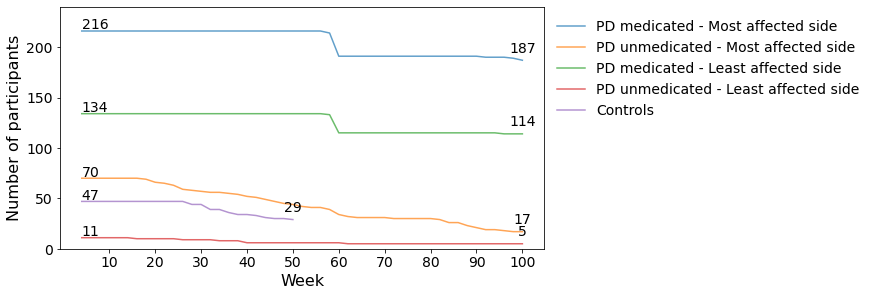

In [34]:
group_rename = {
    'pd_mas_med': 'PD medicated - Most affected side',
    'pd_mas_no_med': 'PD unmedicated - Most affected side',
    'pd_las_med': 'PD medicated - Least affected side',
    'pd_las_no_med': 'PD unmedicated - Least affected side',
    'controls': 'Controls'
}

fig, ax = plt.subplots(figsize=(12,4), constrained_layout=True)

signal_or_measurements = 'signal'
filter_type = 'filtered'
method = 'full'

df_static_n_subjects = df_srm_static.loc[
    (df_srm_static['signal_or_measurements'] == signal_or_measurements) &
    (df_srm_static['filter_type'] == filter_type) &
    (df_srm_static['method'] == method)
]

for group in df_static_n_subjects['group'].unique():
    df_median_group = df_static_n_subjects.loc[
        (df_static_n_subjects['group'] == group) & 
        (df_static_n_subjects['measure'] == 'median') & 
        (df_static_n_subjects['scope'].isin([f'dynamic_{x}' for x in all_weeks_2y])) &
        (df_static_n_subjects['segment_length'] == '20_inf')] 

    ax.plot(
        df_median_group['scope'], 
        df_median_group['N'], 
        label=group_rename[group], 
        linestyle='-', 
        markersize=8, 
        alpha=0.7,
    )

    ax.text(
        df_median_group['scope'].values[0], 
        df_median_group['N'].values[0] + 6, 
        f"{df_median_group['N'].values[0]}",
        fontsize=PLOT_TEXTSIZE, 
        ha='left', 
        va='center',
    )

    ax.text(
        df_median_group['scope'].values[-1], 
        df_median_group['N'].values[-1] + 5, 
        f"{df_median_group['N'].values[-1]}",
        fontsize=PLOT_TEXTSIZE,
        ha='center',
        va='bottom',
    )

tick_locs = [w / 2 for w in all_weeks_2y if w % 10 == 6]
ax.set_xticks(tick_locs)
ax.set_xticklabels(np.arange(10, 101, 10))
ax.tick_params(axis='both', labelsize=PLOT_TICKSIZE)

ax.set_ylim([0, 240])

plt.ylabel('Number of participants', fontsize=PLOT_LABELSIZE)
plt.xlabel('Week', fontsize=PLOT_LABELSIZE)

plt.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=PLOT_LEGEND_FONTSIZE, frameon=False)
plt.show()

if save_plots:
    fig.savefig(os.path.join(PATH_FIGURES, 'r_surv_curve.png'), dpi=600, bbox_inches='tight')
    fig.savefig(os.path.join(PATH_FIGURES, 'vectors', 'r_surv_curve.pdf'), dpi=600, bbox_inches='tight')

#### Plot 2-year SRM

C:\Users\z665206\AppData\Local\Temp\ipykernel_16888\1506912800.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_srm_dynamic['side'] = df_srm_dynamic['group'].apply(lambda x: x.split('_')[1] if '_' in x else x)
C:\Users\z665206\AppData\Local\Temp\ipykernel_16888\1506912800.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_srm_dynamic['group'] = df_srm_dynamic['group'].apply(lambda x: x.replace('_mas', '').replace('_las', ''))
C:\Users\z665206\AppData\Local\Temp\ipykernel_16888\1506912800.py:63: 

PD medicated mas (weighted) with 216 participants at start and 187 at end.
PD medicated las (weighted) with 134 participants at start and 114 at end.
PD unmedicated mas (weighted) with 70 participants at start and 17 at end.


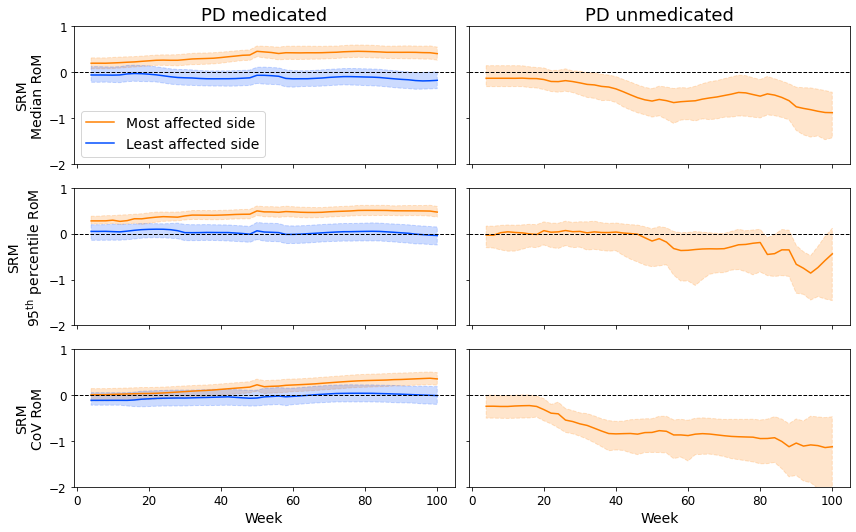

In [62]:
static_or_dynamic = 'dynamic'
segment_length = '0_20'
signal_or_measurements = 'signal'
filter_type = 'filtered'
method = 'full'
updrs_score = 'updrs_3_hypokinesia_off_ws'
plot_updrs = False
weighted_bool = True
show_las_no_med = False

df_srm_dynamic = df_srm.loc[
    (df_srm['segment_length'] == segment_length) &
    (df_srm['signal_or_measurements'] == signal_or_measurements) &
    (df_srm['filter_type'] == filter_type) &
    (df_srm['method'] == method)
]
df_srm_dynamic['side'] = df_srm_dynamic['group'].apply(lambda x: x.split('_')[1] if '_' in x else x)
df_srm_dynamic['group'] = df_srm_dynamic['group'].apply(lambda x: x.replace('_mas', '').replace('_las', ''))

weekly_srm = {}

fig, ax = plt.subplots(nrows=len(measures), ncols=2, figsize=(12,len(measures)*2.5), sharex=True, sharey=False)

for i, measure in enumerate(measures):
    for j, group in enumerate(['pd_med', 'pd_no_med']):
        for side in ['mas', 'las']:
            if not show_las_no_med and side == 'las' and group == 'pd_no_med':
                continue

            plot_color = COLOR_GROUP_1 if side == 'mas' else COLOR_GROUP_2

            df_focus = df_srm_dynamic.loc[
                (df_srm_dynamic['group'] == group) & 
                (df_srm_dynamic['side'] == side) & 
                (df_srm_dynamic['scope'].isin([f'{static_or_dynamic}_{week}' for week in final_weeks_2y] + ['1y', '2y']))
            ].copy()

            if group == 'pd_no_med' and side == 'las':
                linestyle = '--'
                hatchstyle = '--'
                alpha_ci = 0.1
            else:
                linestyle = '-'
                hatchstyle = None
                alpha_ci = 0.2

            if weighted_bool in df_focus['weighted'].values:
                df_subset = df_focus.loc[df_focus['weighted'] == weighted_bool]
            else:
                continue

            if weighted_bool:
                weighted_name = 'weighted'
            else:
                weighted_name = 'unweighted'

            df_subset_measure = df_subset.loc[df_subset['measure'] == measure]
            df_subset_updrs = df_subset.loc[df_subset['measure'] == updrs_score]

            df_subset_updrs.loc[df_subset_updrs['scope'] == '1y', 'scope'] = 50
            df_subset_updrs.loc[df_subset_updrs['scope'] == '2y', 'scope'] = 100

            df_subset_measure['scope'] = [int(x.split('_')[1]) for x in df_subset_measure['scope']]

            min_week = df_subset_measure['scope'].min()
            max_week = df_subset_measure['scope'].max()

            n_start = df_subset_measure.loc[df_subset_measure['scope'] == min_week, 'N'].values[0]
            n_end = df_subset_measure.loc[df_subset_measure['scope'] == max_week, 'N'].values[0]

            if measure == '95p':
                print(f"{GROUP_RENAMING[group]} {side} ({weighted_name}) with {n_start} participants at start and {n_end} at end.")

            df_subset_measure = df_subset_measure.sort_values(by='scope')

            ax[i, j].plot(df_subset_measure['scope'], df_subset_measure['SRM'], linestyle=linestyle, color=plot_color, label=f'{AFFECTED_SIDE_RENAMING[side]}')

            if plot_updrs:
                ax[i, j].errorbar(
                    df_subset_updrs['scope'], 
                    df_subset_updrs['SRM'],
                    yerr=[df_subset_updrs['ci_upper'] - df_subset_updrs['SRM'], df_subset_updrs['SRM'] - df_subset_updrs['ci_lower']], 
                    fmt='o', 
                    color=plot_color, 
                    capsize=5 
                )

            ax[i, j].fill_between(df_subset_measure['scope'], df_subset_measure['ci_lower'], df_subset_measure['ci_upper'], alpha=alpha_ci, color=plot_color, linestyle='--')
    
        ax[i, j].tick_params(axis='both', labelsize=PLOT_TICKSIZE)
        ax[i, j].axhline(0, color='black', linestyle='--', linewidth=1)

        if i == 2:
            ax[i, j].set_xlabel('Week', size=PLOT_LABELSIZE)
        elif i == 0:
            ax[i, j].set_title(GROUP_RENAMING[group], size=PLOT_TITLESIZE)

    ax[i, 0].set_ylabel(f'SRM\n{measure_extended_map[measure]}', size=PLOT_LABELSIZE)

ax[0,0].legend(
    loc='lower left', 
    fontsize=PLOT_LEGEND_FONTSIZE, 
    frameon=True, 
)

y_min = -2
y_max = 1

for i in range(len(measures)):
    for j in range(2):
        ax[i, j].set_ylim([y_min, y_max])

for i in range(len(measures)):
    for j in range(2):
        ax[i, j].set_yticks(np.arange(y_min, y_max + 0.1, 1))

        if j == 1:
            ax[i, j].set_yticklabels([])

plt.tight_layout()
plt.show()

if weighted_bool:
    weighted_str = 'weighted'
else:
    weighted_str = 'unweighted'

if save_plots and not l1tf_phased:
    if filter_type == 'filtered' and weighted_bool and signal_or_measurements == 'signal':
        prefix = 'r'
    else:
        prefix = 'sr'
    
    if signal_or_measurements == 'signal':
        filename = f'{prefix}_{weighted_str}_srm_{filter_type}_gait_{segment_length}'
    else:
        filename = f'{prefix}_{weighted_str}_srm_{filter_type}_gait_{segment_length}_measurements'
    
    fig.savefig(os.path.join(PATH_FIGURES, f'{filename}.png'), dpi=600, bbox_inches='tight')
    fig.savefig(os.path.join(PATH_FIGURES, 'vectors', f'{filename}.pdf'), dpi=600, bbox_inches='tight')

#### Controls

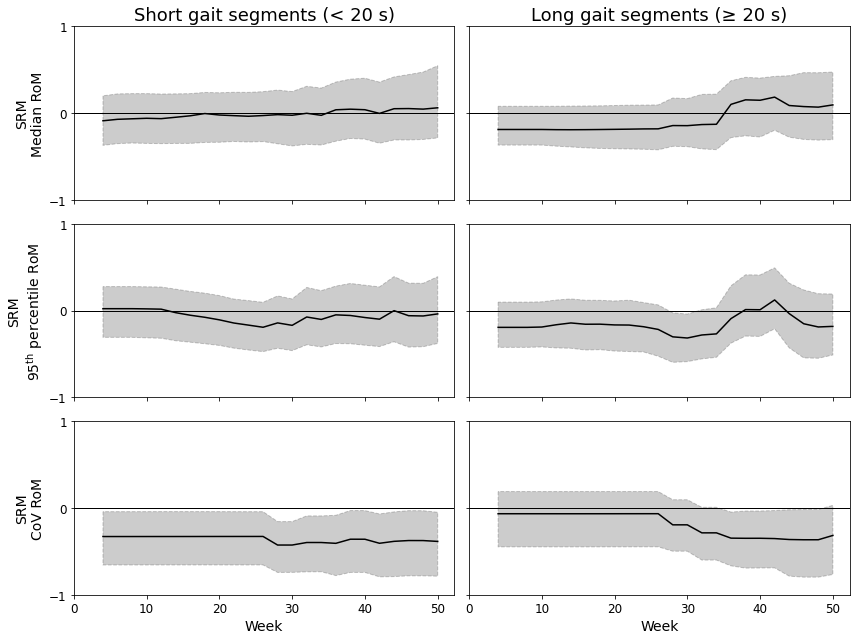

In [63]:
static_or_dynamic = 'dynamic'
group = 'controls'

plot_color = 'black'
linestyle = '-'
hatchstyle = None
alpha_ci = 0.2

fig, ax = plt.subplots(nrows=len(measures), ncols=2, figsize=(12,len(measures) * 3), sharex=True, sharey=True)

weekly_srm = {}

for i, measure in enumerate(measures):
    for j, segment_length in enumerate(['0_20', '20_inf']):
        
        df_focus = df_srm.loc[
            (df_srm['group'] == group) & 
            (df_srm['filter_type'] == 'filtered') &
            (df_srm['method'] == 'full') &
            (df_srm['signal_or_measurements'] == 'signal') &
            (df_srm['measure'] == measure) &
            (df_srm['segment_length'] == segment_length) &
            (df_srm['scope'].isin([f'{static_or_dynamic}_{week}' for week in final_weeks_1y]))
        ].copy()

        df_focus['scope'] = [int(x.split('_')[1]) for x in df_focus['scope']]

        min_week = df_focus['scope'].min()
        max_week = df_focus['scope'].max()

        n_start = df_focus.loc[df_focus['scope'] == min_week, 'N'].values[0]
        n_end = df_focus.loc[df_focus['scope'] == max_week, 'N'].values[0]

        # Sort by scope to ensure proper plotting
        df_focus = df_focus.sort_values(by='scope')

        ax[i,j].plot(df_focus['scope'], df_focus['SRM'], linestyle=linestyle, color=plot_color)

        ax[i,j].fill_between(df_focus['scope'], df_focus['ci_lower'], df_focus['ci_upper'], alpha=alpha_ci, color=plot_color, linestyle='--') 

        ax[i,j].tick_params(axis='both', labelsize=PLOT_TICKSIZE)
        ax[i,j].axhline(0, color=plot_color, linestyle=linestyle, linewidth=1)

        if static_or_dynamic == 'static':
            ax[i,j].set_title(SEGMENT_DURATION_RENAMING[segment_length], size=PLOT_TITLESIZE)
            ax[i,j].set_xticks([])
        elif i == 2:
            ax[i,j].set_xlabel('Week', size=PLOT_LABELSIZE)
            ax[i,j].set_xticks([0, 10, 20, 30, 40, 50])
        elif i == 0:
            if j == 0:
                ax[i,j].set_title('Short gait segments (< 20 s)', size=PLOT_TITLESIZE)
            else:
                ax[i,j].set_title('Long gait segments (≥ 20 s)', size=PLOT_TITLESIZE)

        if j == 0:
            ax[i,j].set_ylabel(f'SRM\n{measure_extended_map[measure]}', size=PLOT_LABELSIZE)
            ax[i,j].set_yticks(np.arange(-1, 1.1, 1))

        ax[i,j].set_ylim([-1, 1])

plt.tight_layout()
plt.show()

if save_plots and not l1tf_phased and filter_type == 'filtered':
    fig.savefig(os.path.join(PATH_FIGURES, 'sr_unweighted_srm_controls.png'), dpi=600, bbox_inches='tight')
    fig.savefig(os.path.join(PATH_FIGURES, 'vectors', 'sr_unweighted_srm_controls.pdf'), dpi=600, bbox_inches='tight')

UPDRS Part 3 ON subscore (las) - SRM: -0.32, CI: [-0.55, -0.13], p-value: 0.002
UPDRS Part 3 ON subscore (mas) - SRM: -0.21, CI: [-0.39, -0.05], p-value: 0.005
UPDRS Part 3 OFF subscore (las) - SRM: -0.53, CI: [-0.77, -0.34], p-value: 0.0
UPDRS Part 3 OFF subscore (mas) - SRM: -0.28, CI: [-0.45, -0.12], p-value: 0.0
CoV RoM - Long (las) - SRM: 0.01, CI: [-0.17, 0.2], p-value: 0.912
CoV RoM - Long (mas) - SRM: 0.18, CI: [0.02, 0.33], p-value: 0.035
CoV RoM - Short (las) - SRM: 0.05, CI: [-0.14, 0.25], p-value: 0.57
CoV RoM - Short (mas) - SRM: 0.35, CI: [0.21, 0.49], p-value: 0.0
95th percentile RoM - Long (las) - SRM: 0.03, CI: [-0.18, 0.23], p-value: 0.755
95th percentile RoM - Long (mas) - SRM: 0.45, CI: [0.31, 0.58], p-value: 0.0
95th percentile RoM - Short (las) - SRM: -0.09, CI: [-0.3, 0.11], p-value: 0.38
95th percentile RoM - Short (mas) - SRM: 0.47, CI: [0.35, 0.59], p-value: 0.0
Median RoM - Long (las) - SRM: 0.1, CI: [-0.1, 0.3], p-value: 0.322
Median RoM - Long (mas) - SRM: 

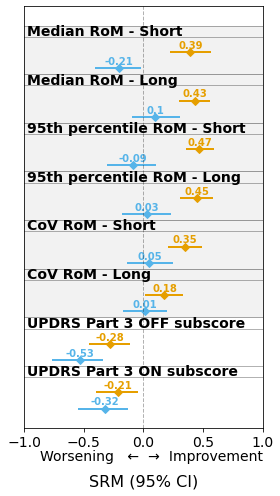

In [48]:
scope = '2y'  # select '1y' or '2y' scope for clinical scores
final_week = 100  # select between week 2 and 104 for measurements
static_or_dynamic = 'dynamic'
signal_or_measurements = 'signal'
filter_type = 'filtered'
method = 'phased'
weighted = True
med_state = 'med'
show_all_sides = False

df_srm_focus = df_srm_static.loc[
    (df_srm_static['weighted'] == weighted) &
    (
        (
            (df_srm_static['scope'] == f'{static_or_dynamic}_{final_week}') & 
            (df_srm_static['filter_type'] == filter_type) &
            (df_srm_static['signal_or_measurements'] == signal_or_measurements) &
            (df_srm_static['method'] == method) 
        ) | (
            (df_srm_static['scope']==scope)
        )
    )
].copy()

df_srm_focus['measure_type'] = df_srm_focus['scope'].apply(
    lambda s: 'clinical' if s in ['1y', '2y'] else 'digital'
)

df_srm_focus['segment_length_trunc'] = df_srm_focus['segment_length'].apply(lambda x: SEGMENT_DURATION_RENAMING[x])
df_srm_focus = df_srm_focus.loc[~((df_srm_focus['segment_length_trunc'] == 'short') & (df_srm_focus['measure_type'] == 'clinical'))].reset_index(drop=True)
df_srm_focus.loc[(df_srm_focus['segment_length_trunc'] == 'long') & (df_srm_focus['measure_type'] == 'clinical'), 'segment_length_trunc'] = ''

df_srm_focus['measure'] = pd.Categorical(df_srm_focus['measure'], categories=focus_score_med_cols)
df_srm_focus['measure_length'] = df_srm_focus.apply(lambda x: x['measure'] if x['measure_type'] == 'clinical' else f"{x['measure']} {x['segment_length']}", axis=1)
df_srm_focus['measure_length_extended'] = df_srm_focus.apply(lambda x: measure_length_map[x['measure_length']] if x['measure_length'] in measure_length_map else x['measure_extended'], axis=1)

df_srm_med_state = df_srm_focus.loc[
    (df_srm_focus['med_status'] == med_state) & 
    (df_srm_focus['measure'].isin([x for x in focus_score_med_cols if 'hypokinesia' in x or x in measures]))
]

df_srm_med_state = df_srm_med_state.sort_values(by=['measure', 'side_extended'])

if med_state == 'no_med' and not show_all_sides:
    df_srm_med_state = df_srm_med_state.loc[df_srm_med_state['side_extended'].str.contains('Most')]

# Flip SRMs for digital measures so that positive = improvement for all
mask = df_srm_med_state['measure_type'] == 'clinical'

df_srm_med_state.loc[mask, 'SRM'] *= -1
ci_lower_flipped = -df_srm_med_state.loc[mask, 'ci_upper']
ci_upper_flipped = -df_srm_med_state.loc[mask, 'ci_lower']

# Assign flipped and swapped bounds
df_srm_med_state.loc[mask, 'ci_lower'] = ci_lower_flipped
df_srm_med_state.loc[mask, 'ci_upper'] = ci_upper_flipped

show_yticks = False

fig, ax = plt.subplots(figsize=(4, 7))

df = df_srm_med_state.sort_values(by=['measure', 'segment_length', 'side'], ascending=[False, False, True]).reset_index(drop=True)
df = df.drop_duplicates(subset=['group', 'measure', 'SRM']).reset_index(drop=True)

within_rate = 0.7
between_rate = 2 * within_rate

if med_state == 'no_med' and not show_all_sides:
    ypos = np.arange(0, 10, 1) * between_rate
else:
    ypos = [0, 1 * within_rate, 1 * within_rate + 1 * between_rate, 2 * within_rate + 1 * between_rate, 
            2 * within_rate + 2 * between_rate, 3 * within_rate + 2 * between_rate, 3 * within_rate + 3 * between_rate,
            4 * within_rate + 3 * between_rate, 4 * within_rate + 4 * between_rate, 5 * within_rate + 4 * between_rate,
            5 * within_rate + 5 * between_rate, 6 * within_rate + 5 * between_rate, 6 * within_rate + 6 * between_rate,
            7 * within_rate + 6 * between_rate, 7 * within_rate + 7 * between_rate, 8 * within_rate + 7 * between_rate,
            8 * within_rate + 8 * between_rate, 9 * within_rate + 8 * between_rate, 9 * within_rate + 9 * between_rate,]

if med_state == 'no_med' and not show_all_sides:
    df = df.loc[df['side'] == 'mas'].reset_index(drop=True)
    df['y_pos'] = ypos[1:len(df)+1]
else:
    df['y_pos'] = ypos[:len(df)]
    

if not show_all_sides and med_state == 'no_med':
    line_spacing = 0.12  # vertical spacing between label and lines
    text_offset = 0.4   # vertical offset for placing the text between the lines
    srm_text_offset = 0.15

    zero_offset = {
        'clinical':  0.75,
        'digital': 0.75
    }
else:
    line_spacing = 0.24
    text_offset = 0.8  
    srm_text_offset = 0.3

    zero_offset = {
        'clinical':  1.6,
        'digital': 1.6
    }
    
# Loop through each row to plot colored bars and error bars
for i, row in df.iterrows():
    if not show_all_sides and row['side'] == 'las' and med_state == 'no_med':
        continue

    color = COLOR_GROUP_1 if row['side'] == 'mas' else COLOR_GROUP_2
    is_dashed_case = med_state == 'no_med' and row['side'] == 'las' and show_all_sides

    linestyle = 'dashed' if is_dashed_case else 'solid' 

    ax.hlines(y=row['y_pos'], xmin=row['ci_lower'], xmax=row['ci_upper'],
              color=color, linestyles=linestyle, linewidth=2, zorder=0.5
    )
   
    ax.plot(row['SRM'], row['y_pos'], marker='D', color=color,
            markersize=6,
            zorder=1
    )

    ax.text(row['SRM'], row['y_pos'] + srm_text_offset,
            f"{np.round(row['SRM'], 2)}" if med_state == 'no_med' and row['side'] == 'las' else f"{np.round(row['SRM'], 2)}",
            va='center', ha='center', fontsize=10, color=color, weight='bold', clip_on=True, zorder=2
    )

    print(f"{row['measure_length_extended']} ({row['side']}) - SRM: {np.round(row['SRM'], 2)}, CI: [{np.round(row['ci_lower'], 2)}, {np.round(row['ci_upper'], 2)}], p-value: {row['pvalue']}")

transform = blended_transform_factory(ax.transAxes, ax.transData)

prev_group = None
spans = []

for i, row in df.iterrows():
    if row['measure_length_extended'] != prev_group:
        if i > 0 and row['measure_type'] == 'digital' and df.loc[i - 1, 'measure_type'] == 'clinical':
            spans.append(y_line_top)

        y_line_top = row['y_pos'] + zero_offset[row['measure_type']] + line_spacing
        y_line_bottom = row['y_pos'] + zero_offset[row['measure_type']] - line_spacing
        y_text = row['y_pos'] + zero_offset[row['measure_type']]
        
        ax.axhline(y=y_line_top, color='black', alpha=0.3, linewidth=1)
        ax.axhline(y=y_line_bottom, color='black', alpha=0.3, linewidth=1)

        ax.text(
            x=0.01,
            y=y_text, 
            s=row['measure_length_extended'],
            fontsize=PLOT_TEXTSIZE,
            fontweight='bold',
            verticalalignment='center',
            horizontalalignment='left',
            transform=transform, 
            clip_on=False,
        )
        prev_group = row['measure_length_extended']

    elif row['measure_type'] == 'digital' and row['side'] == 'mas':
        spans.append(y_line_top)

if len(spans) == 1:
    spans.append(y_line_top)

for start, end in zip(spans, spans[1:]):
    ax.axhspan(ymin=end, ymax=start, color='grey', alpha=0.1, zorder=0)

if not show_all_sides and med_state == 'no_med':
    combined_labels = df['segment_length_trunc'].str.capitalize() + " (N=" + df['N'].astype(str) + ")"
else:
    combined_labels = df['side'] + " (N=" + df['N'].astype(str) + ")"

if show_yticks:
    ax.set_yticks(df['y_pos'])
    ax.set_yticklabels(combined_labels, fontsize=14)
else:
    ax.set_yticks([])

ax.tick_params(axis='x', labelsize=14)
ax.axvline(x=0, linestyle='--', color='black', alpha=0.3, linewidth=1)

if med_state == 'no_med':
    xlabel_extra_text = "Worsening  ←  →  Improvement"
    xpos = -0.15
    ax.set_xlim([-3.1, 1.3])
else:
    xlabel_extra_text = "Worsening   ←  →  Improvement"
    xpos = 0.07
    ax.set_xlim([-1, 1])

plt.text(xpos, -0.05, xlabel_extra_text,
         ha='center', va='top', fontsize=PLOT_TEXTSIZE,
         transform=ax.get_xaxis_transform()
)

plt.xlabel("SRM (95% CI)", fontsize=PLOT_LABELSIZE, labelpad=25)
plt.tick_params(axis='both', labelsize=PLOT_TICKSIZE)

plt.tight_layout()
plt.show()

if save_plots:
    if weighted:
        weighted_str = 'weighted'
        if filter_type == 'filtered':
            prefix = 'r'
        else:
            prefix = 'sr'
    else:
        weighted_str = 'unweighted'
        prefix = 'sr'

    fig.savefig(os.path.join(PATH_FIGURES, f'{prefix}_{weighted_str}_srm_{scope}_{filter_type}_gait_{med_state}.png'), dpi=600, bbox_inches='tight')
    fig.savefig(os.path.join(PATH_FIGURES, 'vectors', f'{prefix}_{weighted_str}_srm_{scope}_{filter_type}_gait_{med_state}.pdf'), dpi=600, bbox_inches='tight')


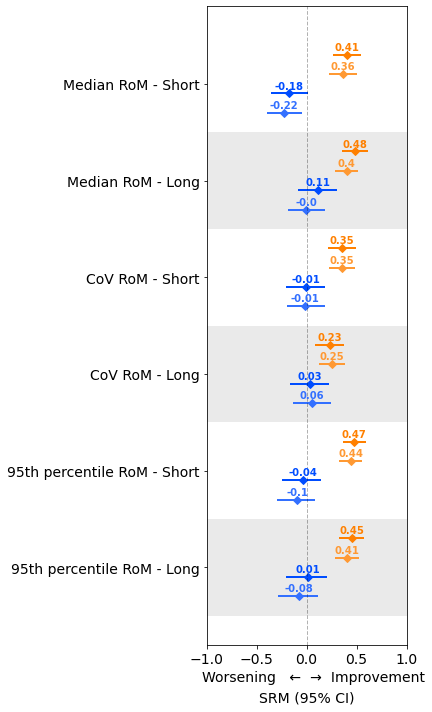

In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.transforms import blended_transform_factory

# --- Config / Parameters ---
scope = '2y'
final_week = 100
static_or_dynamic = 'dynamic'
signal_or_measurements = 'signal'
med_state = 'med'
show_all_sides = False

comparison_method = 'weighting'

if comparison_method not in ['filtering', 'weighting']:
    raise ValueError("comparison_method must be either 'filtering' or 'weighting'")

weighted = True  # set if comparison_method == 'filtering'
filter_type = 'filtered'  # set if comparison_method == 'weighting'

band_colors = ["#BABABA", '#ffffff']  # light gray and white
band_idx = 0
band_width = 1

COLOR_GROUP_1 = (1.0, 0.5, 0.0)  # MAS strong orange
COLOR_GROUP_2 = (0.0, 0.3, 1.0)  # LAS strong blue

PLOT_LABELSIZE = 14
PLOT_TICKSIZE = 12

if scope == '1y' and final_week == 50:
    method = 'phased'
else:
    method = 'full'

def lighten_color(color, amount=0.2):
    """Lighten a color by mixing it with white."""
    return tuple(1 - (1 - x) * (1 - amount) for x in color)

def get_color(side, status):
    base_color = COLOR_GROUP_1 if side == 'mas' else COLOR_GROUP_2
    return base_color if status in ['Filtered', 'Weighted'] else lighten_color(base_color, 0.2)

df_srm_focus = df_srm_static.loc[
    (df_srm_static['method'] == method) &
    (df_srm_static['signal_or_measurements'] == signal_or_measurements) &
    ((df_srm_static['scope'] == scope) | (df_srm_static['scope'] == f'{static_or_dynamic}_{final_week}'))
].copy()

df_srm_focus['filter_status'] = df_srm_focus['filter_type'].map({
    'filtered': 'Filtered',
    'unfiltered': 'Unfiltered'
})

df_srm_focus['weighting_status'] = df_srm_focus['weighted'].map({
    True: 'Weighted',
    False: 'Unweighted'
})

if comparison_method == 'filtering':
    df_srm_focus = df_srm_focus.loc[df_srm_focus['weighted'] == weighted]
    focus_variable = 'filter_status'
    focus_variable_values = ['Filtered', 'Unfiltered']
    default_value = 'Filtered'
elif comparison_method == 'weighting':
    df_srm_focus = df_srm_focus.loc[df_srm_focus['filter_type'] == filter_type]
    focus_variable = 'weighting_status'
    focus_variable_values = ['Weighted', 'Unweighted']
    default_value = 'Weighted'

if not show_all_sides and med_state == 'no_med':
    df_srm_focus = df_srm_focus.loc[~((df_srm_focus['side'] == 'las') & (df_srm_focus['med_status'] == 'no_med'))].reset_index(drop=True)

# Add measure type
df_srm_focus['measure_type'] = df_srm_focus['scope'].apply(
    lambda s: 'clinical' if s in ['1y', '2y'] else 'digital'
)

# Segment length renaming
df_srm_focus['segment_length_trunc'] = df_srm_focus['segment_length'].apply(lambda x: SEGMENT_DURATION_RENAMING[x])
df_srm_focus = df_srm_focus.loc[
    ~((df_srm_focus['segment_length_trunc'] == 'short') & (df_srm_focus['measure_type'] == 'clinical'))
].reset_index(drop=True)
df_srm_focus.loc[
    (df_srm_focus['segment_length_trunc'] == 'long') & (df_srm_focus['measure_type'] == 'clinical'),
    'segment_length_trunc'
] = ''

# Measure length
df_srm_focus['measure_length'] = df_srm_focus.apply(
    lambda x: x['measure'] if x['measure_type'] == 'clinical' else f"{x['measure']} {x['segment_length']}", axis=1
)
df_srm_focus['measure_length_extended'] = df_srm_focus.apply(
    lambda x: measure_length_map.get(x['measure_length'], x['measure_extended']),
    axis=1
)

# --- Subset to med_state and measures of interest ---
df_srm_med_state = df_srm_focus.loc[
    (df_srm_focus['med_status'] == med_state) &
    (df_srm_focus['measure'].isin([x for x in focus_score_med_cols if 'hypokinesia' in x or x in measures]))
].sort_values(by=['measure', 'side_extended', focus_variable]).reset_index(drop=True)

# Flip SRMs for clinical measures
mask = df_srm_med_state['measure_type'] == 'clinical'
df_srm_med_state.loc[mask, 'SRM'] *= -1
df_srm_med_state.loc[mask, ['ci_lower', 'ci_upper']] = -df_srm_med_state.loc[mask, ['ci_upper', 'ci_lower']].values


# In case of filtering, only keep on line per clinical measure (filtered / unfiltered are identical for clinical measures)
if comparison_method == 'filtering':
    df_clinical = df_srm_med_state[df_srm_med_state['measure_type'] == 'clinical'].drop_duplicates(
        subset=['measure', 'side_extended'], keep='first'
    )
else:
    df_clinical = df_srm_med_state[df_srm_med_state['measure_type'] == 'clinical']

df_digital = df_srm_med_state[df_srm_med_state['measure_type'] == 'digital']

df_plot = pd.concat([df_clinical, df_digital], ignore_index=True)

df_plot['color'] = df_plot.apply(
    lambda r: get_color(r['side'], r.get(focus_variable, default_value)), axis=1
)

# --- Assign y-positions (hierarchical: filtered/unfiltered MAS/LAS) ---
y_positions = []
current_y = 0
within_offset = 1   # small gap between filtered and unfiltered
side_offset = 1     # slightly larger gap between MAS and LAS
between_measure = 2.0 # gap between measure-segment combinations

# Group by measure-length combination
group_cols = ['measure_length_extended']
df_plot = df_plot.sort_values(by=group_cols + ['side_extended', focus_variable]).reset_index(drop=True)

for measure, group in df_plot.groupby(group_cols, sort=False):
    for side in ['mas', 'las']:
        side_group = group[group['side'] == side]
        for status in focus_variable_values:
            row_idx = side_group[side_group[focus_variable] == status].index
            if len(row_idx) == 0:
                continue
            y_positions.extend([current_y] * len(row_idx))
            # Increment y for next line
            if status == default_value:
                current_y += within_offset
            else:
                current_y += side_offset
    # Add larger gap to next measure
    current_y += between_measure - side_offset  # subtract last side_offset to avoid double counting

df_plot['y_pos'] = y_positions

# --- Determine tick positions and labels (one per measure-length combination) ---
tick_positions = []
tick_labels = []

for measure, group in df_plot.groupby('measure_length_extended', sort=False):
    y_middle = group['y_pos'].mean()  # middle of the 4 lines
    tick_positions.append(y_middle)
    tick_labels.append(measure)

# --- Plot ---
fig, ax = plt.subplots(figsize=(6, 10))

for measure, group in df_plot.groupby('measure_length_extended', sort=False):
    y_min = group['y_pos'].min() - band_width
    y_max = group['y_pos'].max() + band_width
    ax.axhspan(y_min, y_max, facecolor=band_colors[band_idx % len(band_colors)], alpha=0.3, zorder=0)
    band_idx += 1

for _, row in df_plot.iterrows():
    
    ax.hlines(
        y=row['y_pos'], xmin=row['ci_lower'], xmax=row['ci_upper'],
        color=row['color'], linewidth=2
    )
    ax.plot(row['SRM'], row['y_pos'], marker='D', color=row['color'], markersize=6)
    ax.text(
        row['SRM'], row['y_pos'] + 0.4,
        f"{np.round(row['SRM'], 2)}", ha='center', va='center', fontsize=10, color=row['color'], weight='bold'
    )
if med_state == 'no_med':
    xlabel_extra_text = "Worsening  ←  →  Improvement"
    xpos = -0.15
    ax.set_xlim([-2.5, 2.5])
else:
    xlabel_extra_text = "Worsening   ←  →  Improvement"
    xpos = 0.07
    ax.set_xlim([-1, 1])

plt.text(xpos, -0.04, xlabel_extra_text,
         ha='center', va='top', fontsize=PLOT_TEXTSIZE,
         transform=ax.get_xaxis_transform()
)

# --- Axes formatting ---
ax.axvline(x=0, linestyle='--', color='black', alpha=0.3, linewidth=1)
ax.set_xlabel("SRM (95% CI)", fontsize=PLOT_LABELSIZE, labelpad=25)
ax.set_yticks(tick_positions)
ax.set_yticklabels(tick_labels, fontsize=PLOT_LABELSIZE)
ax.tick_params(axis='x', labelsize=PLOT_LABELSIZE)
plt.tight_layout()
plt.show()

if save_plots:
    prefix = 'sr'

    if comparison_method == 'weighting':
        filename_detail = filter_type
    else:
        filename_detail = 'weighted' if weighted else 'unweighted'

    fig.savefig(os.path.join(PATH_FIGURES, f'{prefix}_comparing_{comparison_method}_srm_{scope}_{filename_detail}_gait_{med_state}.png'), dpi=600, bbox_inches='tight')
    fig.savefig(os.path.join(PATH_FIGURES, 'vectors', f'{prefix}_{weighted_str}_srm_{scope}_{filter_type}_gait_{med_state}.pdf'), dpi=600, bbox_inches='tight')